# Chapter 4. Training Models

Up until now we have treated machine learning models and their training algorithms mostly like black boxes. Knowing how things work under the hood is critical for a Data Scientist or a Machine Learning Engineer. It helps you quickly zero in on the appropriate model the right training algorithm and a good set of hyperparameters for your task.

We will start by looking at the Linear Regression model.

## Linear Regression

A linear model makes a prediction by simply computing a weighted sum of the input features plus a constant called the bias term. To train this model we must find the parameters that minimize the Mean Squared Error over the training set.

### The Normal Equation

The Normal Equation is a closed form mathematical solution that analytically computes the optimal parameters in a single step.

$$\hat{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

Let's generate some linear looking data to test this equation.

In [6]:
import numpy as np
import matplotlib.pyplot as plt 

rng = np.random.default_rng(seed=42)
m = 200 # Number of instances
X = 2 * rng.random((m, 1)) # Column vector
y = 4 + 3 * X + rng.standard_normal((m, 1)) # y = 4 + 3X + Gaussian noise

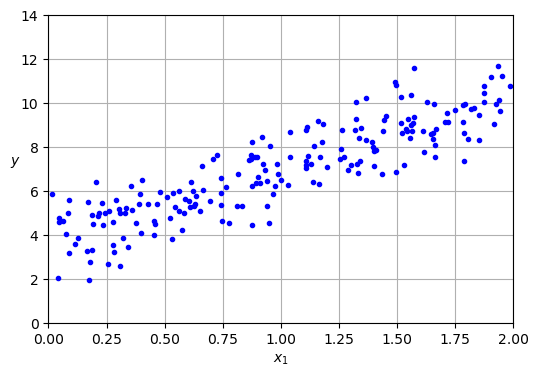

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, 'b.')
plt.grid()
plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation=0)
plt.axis([0, 2, 0, 14])
plt.show()

The actual mathematical function we used to generate the data is $y = 4 + 3x_1$ plus some random noise. Now we will use the Normal Equation to compute the optimal parameters and see how close they are to the true values of 4 and 3.

In [9]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print('Theta best analytically calculated:\n', theta_best)

Theta best analytically calculated:
 [[3.69084138]
 [3.32960458]]


The noise prevented us from recovering the exact parameters of 4 and 3. Now we can make predictions using these computed parameters.

In [19]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
print('Predicted values:\n', y_predict)

Predicted values:
 [[ 3.69084138]
 [10.35005055]]


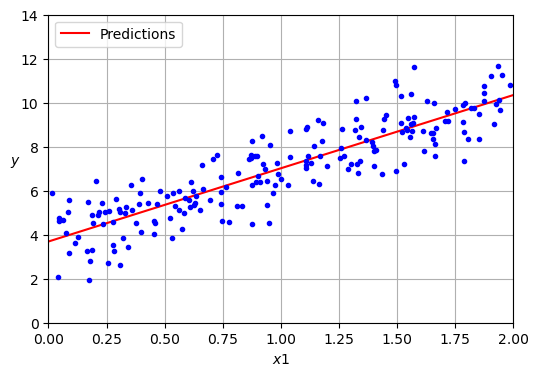

In [41]:
plt.figure(figsize=(6, 4))
plt.plot(X_new, y_predict, 'r-', label='Predictions')
plt.plot(X, y, 'b.')
plt.xlabel('$x1$')
plt.ylabel('$y$', rotation=0)
plt.axis([0, 2, 0, 14])
plt.grid()
plt.legend(loc='upper left')
plt.show()

Performing linear regression using Scikit-learn is straightforward and much simpler.

In [52]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print('Intercept:', lin_reg.intercept_)
print('Coefficients:', lin_reg.coef_)

sklearn_predictions = lin_reg.predict(X_new)
print('\nScikit-learn Predictions:\n', sklearn_predictions)

Intercept: [3.69084138]
Coefficients: [[3.32960458]]

Scikit-learn Predictions:
 [[ 3.69084138]
 [10.35005055]]


The `LinearRegression` class is actually based on the `scipy.linalg.lstsq` function which stands for least squares. We can call this underlying mathematical function directly to see how Scikit Learn computes the optimal parameters.

In [62]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
print('Theta best using SVD:\n', theta_best_svd)

Theta best using SVD:
 [[3.69084138]
 [3.32960458]]


This function computes $\hat{\theta} = \mathbf{X}^+\mathbf{y}$ where $\mathbf{X}^+$ is the pseudoinverse of $\mathbf{X}$. We can also use NumPy to compute this pseudoinverse directly.

In [70]:
theta_best_pinv = np.linalg.pinv(X_b) @ y
print('Theta best using pinv:\n', theta_best_pinv)

Theta best using pinv:
 [[3.69084138]
 [3.32960458]]


The pseudoinverse itself is computed using a standard matrix factorization technique called Singular Value Decomposition. SVD decomposes the training set matrix $\mathbf{X}$ into the matrix multiplication of three distinct matrices $\mathbf{U} \mathbf{\Sigma} \mathbf{V}^\top$. The pseudoinverse is then mathematically computed as $\mathbf{X}^+ = \mathbf{V} \mathbf{\Sigma}^+ \mathbf{U}^\top$. This SVD approach is significantly more robust than computing the Normal Equation. The Normal Equation completely fails if the matrix $\mathbf{X}^\top\mathbf{X}$ is singular meaning it is not invertible. This happens when there are more features than training instances or when certain features are perfectly redundant. The pseudoinverse on the other hand is always defined.

### Computational Complexity

A critical engineering consideration is how these algorithms scale with data size. The Normal Equation computes the inverse of an $(n + 1) \times (n + 1)$ matrix where $n$ is the number of features. The computational complexity of inverting such a matrix is typically about $O(n^{2.4})$ to $O(n^3)$. This means if you double the number of features you multiply the computation time by roughly 5.3 to 8 times. The SVD approach used by Scikit Learn is much more efficient at roughly $O(n^2)$. If you double the number of features you only multiply the computation time by roughly 4. However both the Normal Equation and the SVD approach get exceptionally slow when the number of features grows extremely large such as 100000. On the positive side both algorithms are linear with regard to the number of training instances $O(m)$. They handle massive training datasets efficiently provided the data fits securely in the computer's memory. Also once a linear regression model is trained making predictions is extremely fast. The computational complexity is linear with regard to both the instances and the features. Now we will look at a completely different way to train a linear regression model which is specifically optimized for cases where there are an enormous number of features or when the training dataset is simply too large to fit in memory.